In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import glob

In [5]:
# Find all files in the current working directory that end with .csv
files = glob.glob("*.csv")

In [6]:
# Return the list of matched CSV filenames
files

['competitor_data.csv',
 'kitchen_costs.csv',
 'menu_items.csv',
 'orders_data.csv',
 'weather_data.csv']

In [7]:
 # Create an empty dictionary to store our DataFrames
dataframes = {}

# Loop through each CSV file path in the files list
for file in files:
    name = file.split("\\")[-1].replace(".csv", "")
     # Read the CSV file into a pandas DataFrame
    dataframes[name] = pd.read_csv(file)

In [ ]:
# Return a dictionary of the dataframes
dataframes

In [13]:
# Retrieve specific DataFrames from the dictionary by key.
competitor_df = dataframes.get("competitor_data")
kitchen_cost_df = dataframes.get("kitchen_costs")
menu_df = dataframes.get("menu_items")
orders_df = dataframes.get("orders_data")
weather_df = dataframes.get("weather_data")

In [14]:
competitor_df.head()

,location,num_competing_restaurants,num_delivery_only_competitors,avg_competitor_rating,avg_competitor_delivery_time
0,Kilimani,45,8,4.1,42
1,Westlands,62,12,4.2,45
2,Eastleigh,38,3,3.8,35


In [15]:
kitchen_cost_df.head()

,location,monthly_rent,monthly_utilities,monthly_staff_cost,monthly_licenses,equipment_depreciation,total_monthly_fixed_cost
0,Kilimani,180000,35000,150000,25000,18000,408000
1,Westlands,220000,42000,150000,25000,18000,455000
2,Eastleigh,130000,28000,120000,20000,15000,313000


In [44]:
menu_df.head(10)

,item_name,prep_time,cost,price
0,Pilau,25,180,450
1,Nyama Choma Platter,35,350,850
2,Ugali & Fish,20,200,500
3,Chicken Biriyani,30,220,550
4,Samosa (6pc),10,60,200
5,Mandazi (4pc),8,40,150
6,Chips Masala,15,80,250
7,Bhajia,12,70,220
8,Matoke & Beef,28,190,480
9,Githeri Special,22,120,350


In [17]:
orders_df.head()

,order_id,location,order_datetime,items,num_items,subtotal,delivery_fee,total,delivery_time_minutes,customer_rating,is_weekend,is_rainy,hour
0,1000,Kilimani,01/08/2024 19:15,Matoke & Beef,1,480,100,580,57,4.5,False,False,19
1,1001,Kilimani,01/08/2024 12:01,Pilau,1,450,100,550,52,5.0,False,False,12
2,1002,Kilimani,01/08/2024 20:14,Nyama Choma Platter,1,850,0,850,67,3.0,False,False,20
3,1003,Kilimani,01/08/2024 13:13,Nyama Choma Platter|Chicken Biriyani|Pilau,3,1850,0,1850,73,2.5,False,False,13
4,1004,Kilimani,01/08/2024 12:46,Chicken Biriyani,1,550,0,550,59,5.0,False,False,12


In [18]:
weather_df.head()

,date,rainfall_mm,temperature_celsius
0,2024-08-01,0.0,18.878250
1,2024-08-02,0.0,27.594026
2,2024-08-03,0.0,23.398712
3,2024-08-04,0.0,18.719038
4,2024-08-05,0.0,22.715507


In [21]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21363 entries, 0 to 21362
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               21363 non-null  int64  
 1   location               21363 non-null  object 
 2   order_datetime         21363 non-null  object 
 3   items                  21363 non-null  object 
 4   num_items              21363 non-null  int64  
 5   subtotal               21363 non-null  int64  
 6   delivery_fee           21363 non-null  int64  
 7   total                  21363 non-null  int64  
 8   delivery_time_minutes  21363 non-null  int64  
 9   customer_rating        21363 non-null  float64
 10  is_weekend             21363 non-null  bool   
 11  is_rainy               21363 non-null  bool   
 12  hour                   21363 non-null  int64  
dtypes: bool(2), float64(1), int64(7), object(3)
memory usage: 1.8+ MB


In [22]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 184 non-null    object 
 1   rainfall_mm          184 non-null    float64
 2   temperature_celsius  184 non-null    float64
dtypes: float64(2), object(1)
memory usage: 4.4+ KB


In [23]:
menu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   item_name  10 non-null     object
 1   prep_time  10 non-null     int64 
 2   cost       10 non-null     int64 
 3   price      10 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 452.0+ bytes


In [27]:
# Make copies of the original DFs which we will use in the analysis
orders = orders_df.copy()
menu = menu_df.copy()
weather = weather_df.copy()
cost = kitchen_cost_df.copy()
competitors = competitor_df.copy()

In [35]:
orders.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,21363.0,11681.000000,6167.111236,1000.0,6340.5,11681.0,17021.5,22362.0
num_items,21363.0,1.496232,0.668638,1.0,1.0,1.0,2.0,3.0
subtotal,21363.0,691.538642,412.288725,150.0,450.0,550.0,850.0,1900.0
delivery_fee,21363.0,36.235547,48.069200,0.0,0.0,0.0,100.0,100.0
total,21363.0,727.774189,379.946068,250.0,500.0,570.0,850.0,1900.0
delivery_time_minutes,21363.0,63.737443,14.172223,28.0,54.0,64.0,73.0,107.0
customer_rating,21363.0,3.731569,0.799642,1.0,3.0,3.5,4.5,5.0
hour,21363.0,16.156205,3.411855,11.0,13.0,15.0,20.0,22.0


In [36]:
weather.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
rainfall_mm,184.0,5.674942,11.377539,0.000000,0.000000,0.000000,1.154522,44.237347
temperature_celsius,184.0,23.131366,3.034444,18.091956,20.496478,23.401892,25.784919,27.991457


## Data Cleaning
* Convert date columns in orders and weather dataframes to datetime since the data type is object

In [45]:
orders["order_datetime"] = pd.to_datetime(
    orders["order_datetime"],
    dayfirst=True
)

In [33]:
weather["date"] = pd.to_datetime(
    weather["date"]
)

* Check for duplicates

In [34]:
orders["order_id"].duplicated().sum()

np.int64(0)

In [50]:
orders.columns

Index(['order_id', 'location', 'order_datetime', 'items', 'num_items',
       'subtotal', 'delivery_fee', 'total', 'delivery_time_minutes',
       'customer_rating', 'is_weekend', 'is_rainy', 'hour'],
      dtype='object')

In [49]:
orders.drop(columns=["order_datetim"], inplace=True)

* Split items column in orders dataframe

In [51]:
orders_split  = (
    orders.assign(clean_item=orders['items'].str.split('|'))
      .explode('clean_item')
)
orders_split['clean_item'] = orders_split['clean_item'].str.strip()
orders_split

,order_id,location,order_datetime,items,num_items,subtotal,delivery_fee,total,delivery_time_minutes,customer_rating,is_weekend,is_rainy,hour,clean_item
0,1000,Kilimani,2024-08-01 19:15:00,Matoke & Beef,1,480,100,580,57,4.5,False,False,19,Matoke & Beef
1,1001,Kilimani,2024-08-01 12:01:00,Pilau,1,450,100,550,52,5.0,False,False,12,Pilau
2,1002,Kilimani,2024-08-01 20:14:00,Nyama Choma Platter,1,850,0,850,67,3.0,False,False,20,Nyama Choma Platter
3,1003,Kilimani,2024-08-01 13:13:00,Nyama Choma Platter|Chicken Biriyani|Pilau,3,1850,0,1850,73,2.5,False,False,13,Nyama Choma Platter
3,1003,Kilimani,2024-08-01 13:13:00,Nyama Choma Platter|Chicken Biriyani|Pilau,3,1850,0,1850,73,2.5,False,False,13,Chicken Biriyani
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21359,22359,Eastleigh,2025-01-31 21:02:00,Chips Masala,1,250,100,350,40,4.5,False,False,21,Chips Masala
21360,22360,Eastleigh,2025-01-31 14:02:00,Chips Masala,1,250,100,350,46,4.5,False,False,14,Chips Masala
21361,22361,Eastleigh,2025-01-31 21:29:00,Mandazi (4pc)|Chips Masala,2,400,100,500,55,4.0,False,False,21,Mandazi (4pc)
21361,22361,Eastleigh,2025-01-31 21:29:00,Mandazi (4pc)|Chips Masala,2,400,100,500,55,4.0,False,False,21,Chips Masala


In [52]:
# Merge orders_split with menu to get cost & price per item
orders_split_menu = orders_split.merge(menu, left_on='clean_item', right_on='item_name', how='left')
orders_split_menu

,order_id,location,order_datetime,items,num_items,subtotal,delivery_fee,total,delivery_time_minutes,customer_rating,is_weekend,is_rainy,hour,clean_item,item_name,prep_time,cost,price
0,1000,Kilimani,2024-08-01 19:15:00,Matoke & Beef,1,480,100,580,57,4.5,False,False,19,Matoke & Beef,Matoke & Beef,28,190,480
1,1001,Kilimani,2024-08-01 12:01:00,Pilau,1,450,100,550,52,5.0,False,False,12,Pilau,Pilau,25,180,450
2,1002,Kilimani,2024-08-01 20:14:00,Nyama Choma Platter,1,850,0,850,67,3.0,False,False,20,Nyama Choma Platter,Nyama Choma Platter,35,350,850
3,1003,Kilimani,2024-08-01 13:13:00,Nyama Choma Platter|Chicken Biriyani|Pilau,3,1850,0,1850,73,2.5,False,False,13,Nyama Choma Platter,Nyama Choma Platter,35,350,850
4,1003,Kilimani,2024-08-01 13:13:00,Nyama Choma Platter|Chicken Biriyani|Pilau,3,1850,0,1850,73,2.5,False,False,13,Chicken Biriyani,Chicken Biriyani,30,220,550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31959,22359,Eastleigh,2025-01-31 21:02:00,Chips Masala,1,250,100,350,40,4.5,False,False,21,Chips Masala,Chips Masala,15,80,250
31960,22360,Eastleigh,2025-01-31 14:02:00,Chips Masala,1,250,100,350,46,4.5,False,False,14,Chips Masala,Chips Masala,15,80,250
31961,22361,Eastleigh,2025-01-31 21:29:00,Mandazi (4pc)|Chips Masala,2,400,100,500,55,4.0,False,False,21,Mandazi (4pc),Mandazi (4pc),8,40,150
31962,22361,Eastleigh,2025-01-31 21:29:00,Mandazi (4pc)|Chips Masala,2,400,100,500,55,4.0,False,False,21,Chips Masala,Chips Masala,15,80,250


In [55]:
# Calculate costs per order level
order_costs = (
    orders_split_menu.groupby('order_id')
    .agg(total_ingredient_cost=('cost', 'sum'))
    .reset_index()
)
order_costs

,order_id,total_ingredient_cost
0,1000,190
1,1001,180
2,1002,350
3,1003,750
4,1004,220
...,...,...
21358,22358,240
21359,22359,80
21360,22360,80
21361,22361,120


In [56]:
# Merge order_costs to orders dataframe
orders_cost_merged = orders.merge(order_costs, on='order_id', how='left')
orders_cost_merged

,order_id,location,order_datetime,items,num_items,subtotal,delivery_fee,total,delivery_time_minutes,customer_rating,is_weekend,is_rainy,hour,total_ingredient_cost
0,1000,Kilimani,2024-08-01 19:15:00,Matoke & Beef,1,480,100,580,57,4.5,False,False,19,190
1,1001,Kilimani,2024-08-01 12:01:00,Pilau,1,450,100,550,52,5.0,False,False,12,180
2,1002,Kilimani,2024-08-01 20:14:00,Nyama Choma Platter,1,850,0,850,67,3.0,False,False,20,350
3,1003,Kilimani,2024-08-01 13:13:00,Nyama Choma Platter|Chicken Biriyani|Pilau,3,1850,0,1850,73,2.5,False,False,13,750
4,1004,Kilimani,2024-08-01 12:46:00,Chicken Biriyani,1,550,0,550,59,5.0,False,False,12,220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21358,22358,Eastleigh,2025-01-31 20:36:00,Pilau|Samosa (6pc),2,650,0,650,45,5.0,False,False,20,240
21359,22359,Eastleigh,2025-01-31 21:02:00,Chips Masala,1,250,100,350,40,4.5,False,False,21,80
21360,22360,Eastleigh,2025-01-31 14:02:00,Chips Masala,1,250,100,350,46,4.5,False,False,14,80
21361,22361,Eastleigh,2025-01-31 21:29:00,Mandazi (4pc)|Chips Masala,2,400,100,500,55,4.0,False,False,21,120


In [59]:
# Calculate gross profit for each order
orders_cost_merged["gross_profit"] = orders_cost_merged["total"] - orders_cost_merged["total_ingredient_cost"]
orders_cost_merged

,order_id,location,order_datetime,items,num_items,subtotal,delivery_fee,total,delivery_time_minutes,customer_rating,is_weekend,is_rainy,hour,total_ingredient_cost,gross_profit
0,1000,Kilimani,2024-08-01 19:15:00,Matoke & Beef,1,480,100,580,57,4.5,False,False,19,190,390
1,1001,Kilimani,2024-08-01 12:01:00,Pilau,1,450,100,550,52,5.0,False,False,12,180,370
2,1002,Kilimani,2024-08-01 20:14:00,Nyama Choma Platter,1,850,0,850,67,3.0,False,False,20,350,500
3,1003,Kilimani,2024-08-01 13:13:00,Nyama Choma Platter|Chicken Biriyani|Pilau,3,1850,0,1850,73,2.5,False,False,13,750,1100
4,1004,Kilimani,2024-08-01 12:46:00,Chicken Biriyani,1,550,0,550,59,5.0,False,False,12,220,330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21358,22358,Eastleigh,2025-01-31 20:36:00,Pilau|Samosa (6pc),2,650,0,650,45,5.0,False,False,20,240,410
21359,22359,Eastleigh,2025-01-31 21:02:00,Chips Masala,1,250,100,350,40,4.5,False,False,21,80,270
21360,22360,Eastleigh,2025-01-31 14:02:00,Chips Masala,1,250,100,350,46,4.5,False,False,14,80,270
21361,22361,Eastleigh,2025-01-31 21:29:00,Mandazi (4pc)|Chips Masala,2,400,100,500,55,4.0,False,False,21,120,380


###

### Exploratory Data Analysis
#### Should quickbites expand?

First check whether the current locations are profitable


In [62]:
# Add month column in order to calculate month-on-month trends
orders_cost_merged['month'] = orders_cost_merged['order_datetime'].dt.to_period('M')

In [67]:
# Monthly trends(total orders, revenue, costs, gross profit) by location
monthly_trends = (
    orders_cost_merged.groupby(['month', 'location'])
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('subtotal', 'sum'),
        ingredient_costs=('total_ingredient_cost', 'sum'),
        gross_profit=('gross_profit', 'sum')
    )
    .reset_index()
)
monthly_trends

,month,location,orders,revenue,ingredient_costs,gross_profit
0,2024-08,Eastleigh,922,496370,185090,355280
1,2024-08,Kilimani,1339,1039520,412480,671640
2,2024-08,Westlands,1120,802870,312030,525240
3,2024-09,Eastleigh,989,547320,204080,391540
4,2024-09,Kilimani,1326,1063520,422770,678850
5,2024-09,Westlands,1114,803080,311870,525410
6,2024-10,Eastleigh,1029,571770,214360,407110
7,2024-10,Kilimani,1389,1086040,431060,697980
8,2024-10,Westlands,1130,794370,308070,522200
9,2024-11,Eastleigh,1192,654140,244570,465370


In [71]:
# Compare monthly costs to the fixed costs for each location
monthly_trends = monthly_trends.merge(
    cost[['location', 'total_monthly_fixed_cost']],
    on='location', how='left'
)
monthly_trends

,month,location,orders,revenue,ingredient_costs,gross_profit,total_monthly_fixed_cost
0,2024-08,Eastleigh,922,496370,185090,355280,313000
1,2024-08,Kilimani,1339,1039520,412480,671640,408000
2,2024-08,Westlands,1120,802870,312030,525240,455000
3,2024-09,Eastleigh,989,547320,204080,391540,313000
4,2024-09,Kilimani,1326,1063520,422770,678850,408000
5,2024-09,Westlands,1114,803080,311870,525410,455000
6,2024-10,Eastleigh,1029,571770,214360,407110,313000
7,2024-10,Kilimani,1389,1086040,431060,697980,408000
8,2024-10,Westlands,1130,794370,308070,522200,455000
9,2024-11,Eastleigh,1192,654140,244570,465370,313000


In [72]:
# Calculate net profit
monthly_trends['net_profit'] = monthly_trends['gross_profit'] - monthly_trends['total_monthly_fixed_cost']
monthly_trends


,month,location,orders,revenue,ingredient_costs,gross_profit,total_monthly_fixed_cost,net_profit
0,2024-08,Eastleigh,922,496370,185090,355280,313000,42280
1,2024-08,Kilimani,1339,1039520,412480,671640,408000,263640
2,2024-08,Westlands,1120,802870,312030,525240,455000,70240
3,2024-09,Eastleigh,989,547320,204080,391540,313000,78540
4,2024-09,Kilimani,1326,1063520,422770,678850,408000,270850
5,2024-09,Westlands,1114,803080,311870,525410,455000,70410
6,2024-10,Eastleigh,1029,571770,214360,407110,313000,94110
7,2024-10,Kilimani,1389,1086040,431060,697980,408000,289980
8,2024-10,Westlands,1130,794370,308070,522200,455000,67200
9,2024-11,Eastleigh,1192,654140,244570,465370,313000,152370


In [73]:
# Total 6-month profitability per location
six_month_pl = (
    monthly_trends.groupby('location')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_ingredient_costs=('ingredient_costs', 'sum'),
        total_gross_profit=('gross_profit', 'sum'),
        total_fixed_costs=('total_monthly_fixed_cost', 'sum'),
        total_net_profit=('net_profit', 'sum'),
        avg_monthly_orders=('orders', 'mean')
    )
    .round(0)
)
six_month_pl

,total_revenue,total_ingredient_costs,total_gross_profit,total_fixed_costs,total_net_profit,avg_monthly_orders
location,,,,,,
Eastleigh,3644090,1362860,2600330,1878000,722330,1106.0
Kilimani,6376140,2531620,4091420,2448000,1643420,1348.0
Westlands,4753110,1844040,3117170,2730000,387170,1106.0


In [74]:
# Merge competitor data with profitability
expansion_profile = six_month_pl.reset_index().merge(
    competitors, on='location', how='left'
)
expansion_profile

,location,total_revenue,total_ingredient_costs,total_gross_profit,total_fixed_costs,total_net_profit,avg_monthly_orders,num_competing_restaurants,num_delivery_only_competitors,avg_competitor_rating,avg_competitor_delivery_time
0,Eastleigh,3644090,1362860,2600330,1878000,722330,1106.0,38,3,3.8,35
1,Kilimani,6376140,2531620,4091420,2448000,1643420,1348.0,45,8,4.1,42
2,Westlands,4753110,1844040,3117170,2730000,387170,1106.0,62,12,4.2,45


**Key Findings:**
- All three ghost kitchens are profitable, validating the model
- Kilimani leads on net profit (KES 1.6M over 6 months), but Eastleigh (KES 722K) is nearly 2x more profitable than Westlands (KES 387K) despite lower revenue
- The most profitable locations have: low fixed costs, few delivery-only competitors, and room to outperform on quality

**Recommendations:**
1. **Expand to neighborhoods that resemble Eastleigh** — low rent (under KES 150K/month), few delivery-only competitors (under 5) and underserved by quality delivery (competitor ratings below 4.0)
2. **Avoid "Westlands-type" locations** — high rent, crowded competitive landscape and thin margins despite decent revenue


#### How weather impacts the business

In [108]:
# Daily orders by location
daily_orders = (
    orders_cost_merged.groupby(['date', 'location', 'is_rainy'])
    .agg(
        orders=('order_id', 'nunique'),
        avg_delivery_time=('delivery_time_minutes', 'mean'),
        revenue=('total', 'sum')
    )
    .reset_index()
)

# Compare rainy vs dry days
weather_impact = (
    daily_orders.groupby(['location', 'is_rainy'])
    .agg(
        avg_daily_orders=('orders', 'mean'),
        avg_delivery_time=('avg_delivery_time', 'mean'),
        avg_daily_revenue=('revenue', 'mean')
    )
    .round(1)
)
weather_impact

avg_daily_orders  avg_delivery_time  avg_daily_revenue
location  is_rainy                                                        
Eastleigh False                 39.4               52.1            23409.4
          True                  28.7               69.5            17371.8
Kilimani  False                 48.2               64.9            39409.3
          True                  34.5               82.6            28387.0
Westlands False                 39.5               60.1            29531.8
          True                  28.4               77.6            21239.8

In [106]:
# Percentage change
dry = weather_impact.xs(False, level='is_rainy')
rainy = weather_impact.xs(True, level='is_rainy')
pct_change = ((rainy - dry) / dry * 100).round(1)
pct_change.columns = ['orders_change_%', 'delivery_time_change_%', 'revenue_change_%']

pct_change

,orders_change_%,delivery_time_change_%,revenue_change_%
location,,,
Eastleigh,-27.2,33.4,-25.8
Kilimani,-28.4,27.3,-28.0
Westlands,-28.1,29.1,-28.1


**Finding:** 
- Rain reduces daily orders by 27% across all locations and increases delivery times by 30%.
  
**Recommendations:**
1. **Run "rainy day" promotions** (e.g.discount codes triggered by weather forecast) to offset the order drop.
2. **Staff extra riders on forecast rain days** to protect delivery times — a delivery time spike risks customer ratings.

####

### What's the real story with Eastleigh?

In [75]:
# Eastleigh vs other locations
location_comparison = orders_cost_merged.groupby('location').agg(
    avg_order_value=('total', 'mean'),
    avg_gross_profit_per_order=('gross_profit', 'mean'),
    avg_rating=('customer_rating', 'mean'),
    avg_delivery_time=('delivery_time_minutes', 'mean'),
    total_orders=('order_id', 'nunique')
).round(2)

location_comparison

,avg_order_value,avg_gross_profit_per_order,avg_rating,avg_delivery_time,total_orders
location,,,,,
Eastleigh,597.14,391.79,4.13,56.40,6637
Kilimani,818.87,505.86,3.40,69.23,8088
Westlands,747.40,469.59,3.74,64.38,6638


In [77]:
# Growth trends
monthly_order_growth = (
    monthly_trends.sort_values('month')
    .groupby('location')['orders']
    .pct_change()
)
monthly_trends['order_growth'] = monthly_order_growth

monthly_revenue_growth = (
    monthly_trends.sort_values('month')
    .groupby('location')['revenue']
    .pct_change()
)
monthly_trends['revenue_growth'] = monthly_revenue_growth

monthly_trends[['month', 'location', 'orders', 'revenue', 'order_growth', 'revenue_growth', 'net_profit']]

,month,location,orders,revenue,order_growth,revenue_growth,net_profit
0,2024-08,Eastleigh,922,496370,NaN,NaN,42280
1,2024-08,Kilimani,1339,1039520,NaN,NaN,263640
2,2024-08,Westlands,1120,802870,NaN,NaN,70240
3,2024-09,Eastleigh,989,547320,0.072668,0.102645,78540
4,2024-09,Kilimani,1326,1063520,-0.009709,0.023088,270850
5,2024-09,Westlands,1114,803080,-0.005357,0.000262,70410
6,2024-10,Eastleigh,1029,571770,0.040445,0.044672,94110
7,2024-10,Kilimani,1389,1086040,0.047511,0.021175,289980
8,2024-10,Westlands,1130,794370,0.014363,-0.010846,67200
9,2024-11,Eastleigh,1192,654140,0.158406,0.144061,152370


In [85]:
# Monthly order growth trends by location
order_growth_pivot = monthly_trends.pivot_table(
    index='month', 
    columns='location', 
    values='order_growth'
).round(3)

order_growth_pivot

location,Eastleigh,Kilimani,Westlands
month,,,
2024-09,0.073,-0.010,-0.005
2024-10,0.040,0.048,0.014
2024-11,0.158,-0.048,-0.029
2024-12,0.036,0.056,0.040
2025-01,0.028,-0.057,-0.092


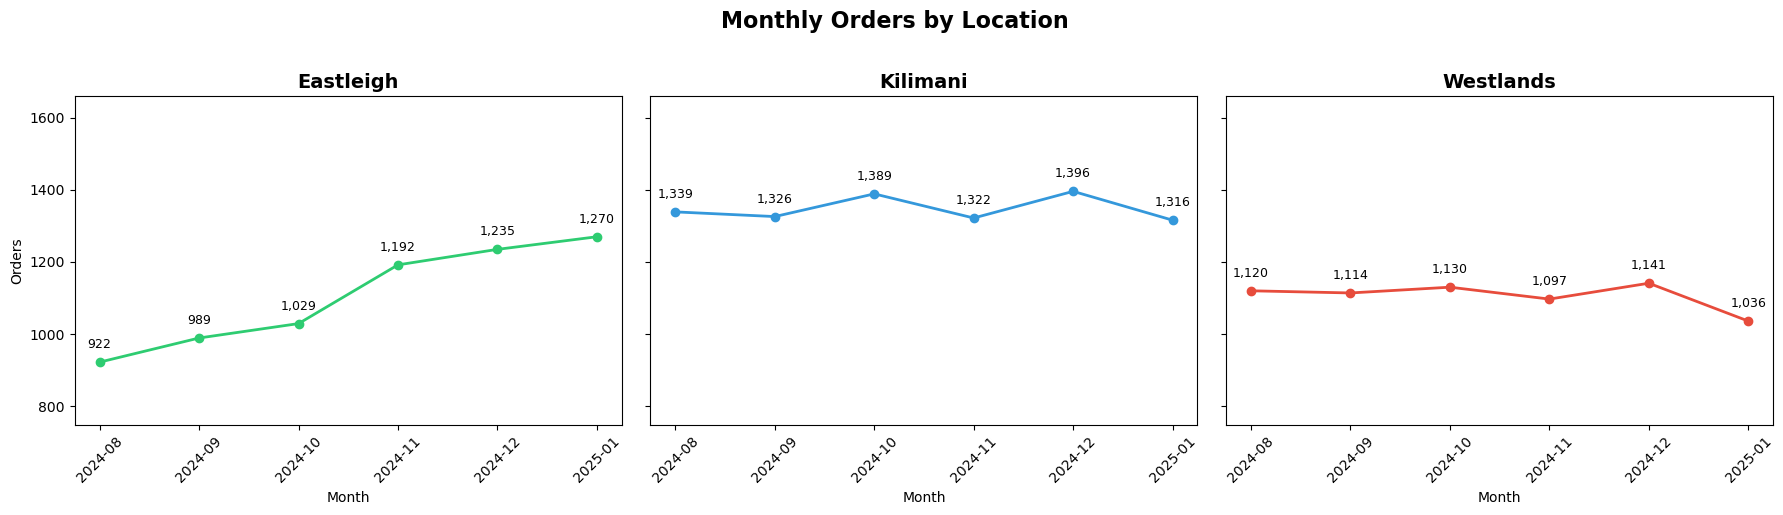

In [100]:
import matplotlib.pyplot as plt

orders_pivot = monthly_trends.pivot_table(
    index='month',
    columns='location',
    values='orders'
)
orders_pivot.index = orders_pivot.index.astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colors = {'Eastleigh': '#2ecc71', 'Kilimani': '#3498db', 'Westlands': '#e74c3c'}

for ax, location in zip(axes, ['Eastleigh', 'Kilimani', 'Westlands']):
    ax.plot(orders_pivot.index, orders_pivot[location], marker='o', linewidth=2, color=colors[location])
    
    # Add data labels
    for x, y in zip(orders_pivot.index, orders_pivot[location]):
        ax.annotate(f'{int(y):,}', (x, y), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)
    
    ax.set_title(location, fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Orders')
fig.suptitle('Monthly Orders by Location', fontsize=16, fontweight='bold', y=1.02)
for ax in axes:
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - 50, ymax + 80)
plt.tight_layout()
plt.show()

In [101]:
# Orders  that each location needs per month to break even
# To help verify whether Eastleigh is 
avg_gross_profit_per_order = (
    orders_cost_merged.groupby('location')['gross_profit']
    .mean()
)

breakeven_orders = (
    cost.set_index('location')['total_monthly_fixed_cost'] 
    / avg_gross_profit_per_order
).round(0)

breakeven_orders

location
Eastleigh    799.0
Kilimani     807.0
Westlands    969.0
dtype: float64

In [81]:
# Comparison between average monthly orders and breakeven orders 
breakeven_table = pd.DataFrame({
    'breakeven_orders_per_month': breakeven_orders,
    'avg_monthly_orders': six_month_pl['avg_monthly_orders']
})

breakeven_table['buffer_pct'] = (
    (breakeven_table['avg_monthly_orders'] - breakeven_table['breakeven_orders_per_month'])
    / breakeven_table['breakeven_orders_per_month']
    * 100
).round(1)

breakeven_table

,breakeven_orders_per_month,avg_monthly_orders,buffer_pct
location,,,
Eastleigh,799.0,1106.0,38.4
Kilimani,807.0,1348.0,67.0
Westlands,969.0,1106.0,14.1


**Key Findings:**
- The CFO's concern is valid on surface metrics — Eastleigh has the lowest order volume and average order value
- However, Eastleigh is the **2nd most profitable** location (KES 722K vs Westlands' KES 387K)
- Eastleigh has the **highest customer rating** (4.13), **fastest delivery** (56 min) and is the **only location with consistent month-over-month growth** (922 to 1,270 orders, +38% over 6 months)
- Eastleigh operates **38% above breakeven** vs Westlands at just 14% — Westlands is the more vulnerable kitchen
- Eastleigh faces only **3 delivery-only competitors** vs 12 in Westlands, giving it significant room to grow

**Recommendations:**
1. **Keep Eastleigh open** and give the GM the requested 3 months, with a clear target: reach 1,300 orders/month by month 9
2. **Invest modestly in local marketing** in Eastleigh to accelerate the organic growth already happening
3. **If cuts are needed, scrutinize Westlands first** — it has the highest costs, most competition, thinnest margins and weakest breakeven buffer

###

### Menu Optimization

In [86]:
# Margins per menu item
menu_analysis = menu.copy()
menu_analysis['margin'] = menu_analysis['price'] - menu_analysis['cost']
menu_analysis['margin_pct'] = ((menu_analysis['margin'] / menu_analysis['price']) * 100).round(1)
menu_analysis['margin_per_minute'] = (menu_analysis['margin'] / menu_analysis['prep_time']).round(1)

menu_analysis.sort_values('margin_per_minute', ascending=False)

,item_name,prep_time,cost,price,margin,margin_pct,margin_per_minute
2,Ugali & Fish,20,200,500,300,60.0,15.0
1,Nyama Choma Platter,35,350,850,500,58.8,14.3
4,Samosa (6pc),10,60,200,140,70.0,14.0
5,Mandazi (4pc),8,40,150,110,73.3,13.8
7,Bhajia,12,70,220,150,68.2,12.5
6,Chips Masala,15,80,250,170,68.0,11.3
3,Chicken Biriyani,30,220,550,330,60.0,11.0
0,Pilau,25,180,450,270,60.0,10.8
9,Githeri Special,22,120,350,230,65.7,10.5
8,Matoke & Beef,28,190,480,290,60.4,10.4


In [87]:
# Item popularity by location
item_popularity = (
    orders_split.groupby(['location', 'clean_item'])
    .size()
    .reset_index(name='times_ordered')
    .sort_values(['location', 'times_ordered'], ascending=[True, False])
)

# Top 5 per location
item_popularity.groupby('location').head(5)

,location,clean_item,times_ordered
7,Eastleigh,Pilau,1960
4,Eastleigh,Mandazi (4pc),1897
8,Eastleigh,Samosa (6pc),1885
1,Eastleigh,Chicken Biriyani,1861
6,Eastleigh,Nyama Choma Platter,418
11,Kilimani,Chicken Biriyani,2892
16,Kilimani,Nyama Choma Platter,2887
17,Kilimani,Pilau,2866
19,Kilimani,Ugali & Fish,508
13,Kilimani,Githeri Special,505


In [91]:
# Total orders per item across all locations
overall_popularity = (
    orders_split.groupby('clean_item')
    .size()
    .reset_index(name='times_ordered')
)

# Merge item popularity data and margins per menu item data
item_matrix = overall_popularity.merge(
    menu_analysis[["item_name", "prep_time", "cost", "price", "margin", 'margin_pct', 'margin_per_minute']],
    left_on='clean_item', right_on='item_name', how='left'
).drop(columns='item_name').sort_values('times_ordered', ascending=False)

item_matrix

,clean_item,times_ordered,prep_time,cost,price,margin,margin_pct,margin_per_minute
1,Chicken Biriyani,7112,30,220,550,330,60.0,11.0
6,Nyama Choma Platter,5691,35,350,850,500,58.8,14.3
7,Pilau,5228,25,180,450,270,60.0,10.8
8,Samosa (6pc),4768,10,60,200,140,70.0,14.0
4,Mandazi (4pc),2752,8,40,150,110,73.3,13.8
3,Githeri Special,1304,22,120,350,230,65.7,10.5
0,Bhajia,1295,12,70,220,150,68.2,12.5
9,Ugali & Fish,1285,20,200,500,300,60.0,15.0
2,Chips Masala,1271,15,80,250,170,68.0,11.3
5,Matoke & Beef,1258,28,190,480,290,60.4,10.4


In [92]:
# Categorize items into performance tiers
def categorize_item(row):
    if row['times_ordered'] > 2000 and row['margin_per_minute'] >= 13:
        return '🟢 Star'
    elif row['margin_per_minute'] >= 12 or row['times_ordered'] > 2000:
        return '🟡 Opportunity'
    else:
        return '🔴 Drag'

item_matrix['category'] = item_matrix.apply(categorize_item, axis=1)

item_matrix.sort_values('margin_per_minute', ascending=False)

,clean_item,times_ordered,prep_time,cost,price,margin,margin_pct,margin_per_minute,category
9,Ugali & Fish,1285,20,200,500,300,60.0,15.0,🟡 Opportunity
6,Nyama Choma Platter,5691,35,350,850,500,58.8,14.3,🟢 Star
8,Samosa (6pc),4768,10,60,200,140,70.0,14.0,🟢 Star
4,Mandazi (4pc),2752,8,40,150,110,73.3,13.8,🟢 Star
0,Bhajia,1295,12,70,220,150,68.2,12.5,🟡 Opportunity
2,Chips Masala,1271,15,80,250,170,68.0,11.3,🔴 Drag
1,Chicken Biriyani,7112,30,220,550,330,60.0,11.0,🟡 Opportunity
7,Pilau,5228,25,180,450,270,60.0,10.8,🟡 Opportunity
3,Githeri Special,1304,22,120,350,230,65.7,10.5,🔴 Drag
5,Matoke & Beef,1258,28,190,480,290,60.4,10.4,🔴 Drag


**specific actions to test:**

**1. Push Samosa and Mandazi as add-ons at checkout**
- Both are Stars: high margin (70-73%), fastest prep (8-10 min) and already popular
- Samosa: KES 14.0/min efficiency, 4,768 orders | Mandazi: KES 13.8/min, 2,752 orders
- **Test:** "Add Samosa or Mandazi to any order for KES 150" upsell prompt — minimal kitchen impact, pure margin boost

**2. Promote Nyama Choma Platter in Eastleigh**
- Highest margin item on the menu (KES 500/order, KES 14.3/min efficiency)
- Popular in Kilimani (2,887 orders) and Westlands (2,386) but underrepresented in Eastleigh (only 418)
- **Test:** Launch a "Nyama Choma meal deal" in Eastleigh for one month — bundle with a side at a slight discount to drive trial

**3. Test removing Matoke & Beef and Githeri Special**
- Both are Drags: bottom 4 in popularity and bottom 2 in prep efficiency
- Matoke & Beef: 1,258 orders, 28 min prep, KES 10.4/min (worst efficiency)
- Githeri Special: 1,304 orders, 22 min prep, KES 10.5/min
- **Test:** Remove both for one month and measure impact on total orders and kitchen throughput. Reallocate freed prep time to high-demand items